Shree Hit


In [71]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image,display


# 1. Define the 'Notebook' (State)
class ResearchState(TypedDict):
    content: str      # The actual text being written
    feedback: str     # Suggestions from the Critic
    iterations: int   # Safety counter to prevent infinite loops

In [72]:
# 2. The 'Worker' Node: Writes or revises content
def writer(state: ResearchState):
    current_iter = state.get('iterations', 0)
    print(f"--- Writer: Starting Attempt {current_iter + 1} ---")
    
    # If there is feedback, the writer 'revises'. Otherwise, it creates.
    if state.get('feedback') and state['feedback'] != "none":
        #new_content = f"Revised version of: [{state['content']}] based on feedback: {state['feedback']}"
        new_content = "By using LangGraph, we can move beyond linear AI chains and build agents that can self-correct and handle multi-step, complex business logic."
    else:
        new_content = state['content'] # Take the initial input
    
        
    return {
        "content": new_content,
        "iterations": current_iter + 1
    }

In [73]:
# 3. The 'Logic' Node: Evaluates the content
def critic(state: ResearchState):
    print(f"--- Critic: Evaluating Content ---")
    content = state['content']
    print("The Content for Evaluation is ==" + content)

    # RULE: Content must be at least 25 characters long to pass
    if len(content) < 25:
        print("--- Critic: REJECTED (Too short) ---")
        return {"feedback": "Too short! Please provide a more detailed explanation."}
    
    print("--- Critic: APPROVED ---")
    return {"feedback": "approved"}

In [74]:
# 4. The 'Router' Function: Decides the next step
def should_continue(state: ResearchState):
    # Exit Condition 1: Critic is happy
    if state["feedback"] == "approved":
        return END
    # Exit Condition 2: Safety stop after 3 attempts
    if state["iterations"] >= 3:
        print("--- System: Max iterations reached. Stopping. ---")
        return END
    # Otherwise: Loop back to the writer
    return "writer"

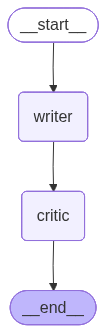

In [75]:
# 5. Build and Compile the Graph
workflow = StateGraph(ResearchState)
workflow.add_node("writer", writer)
workflow.add_node("critic", critic)

workflow.add_edge(START, "writer")
workflow.add_edge("writer", "critic")
workflow.add_conditional_edges("critic", should_continue)

agent = workflow.compile()

graph_image = agent.get_graph().draw_mermaid_png()
display(Image(graph_image))

##Scenario A: The "Loop" (Input is too short)

In [76]:
print("\n--- TEST 1: SHORT INPUT (Triggers Loop) ---")
short_input = {"content": "AI is cool.", "feedback": "none", "iterations": 0}
result_a = agent.invoke(short_input)



--- TEST 1: SHORT INPUT (Triggers Loop) ---
--- Writer: Starting Attempt 1 ---
--- Critic: Evaluating Content ---
The Content for Evaluation is ==AI is cool.
--- Critic: REJECTED (Too short) ---
--- Writer: Starting Attempt 2 ---
--- Critic: Evaluating Content ---
The Content for Evaluation is ==By using LangGraph, we can move beyond linear AI chains and build agents that can self-correct and handle multi-step, complex business logic.
--- Critic: APPROVED ---


###Scenario B: The "Direct Path" (Input is detailed)

In [77]:
print("\n--- TEST 2: LONG INPUT (Passes Immediately) ---")
long_input = {"content": "Agentic AI uses LangGraph to create stateful, cyclic workflows for complex tasks.", 
              "feedback": "none", 
              "iterations": 0}
result_b = agent.invoke(long_input)


--- TEST 2: LONG INPUT (Passes Immediately) ---
--- Writer: Starting Attempt 1 ---
--- Critic: Evaluating Content ---
The Content for Evaluation is ==Agentic AI uses LangGraph to create stateful, cyclic workflows for complex tasks.
--- Critic: APPROVED ---
